
# Evaluación 1

**Autores**: Felipe Ahumada Silva - Francisca Carrasco Lozano

**Fecha de Creación**: Abril 2026


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder

from pathlib import Path

In [2]:
# Carga el set de datos

url_dataset = "https://raw.githubusercontent.com/francarrascoo/Programacion-para-la-ciencia-de-datos/refs/heads/main/data/dataset_clientes.csv"

data = pd.read_csv(url_dataset)

data.head()

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1


## Revisión del estado

In [4]:
# Cantidad de observaciones y columnas
data.shape

(20400, 22)

### Valores faltantes y tipos de datos

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20400 non-null  int64  
 1   fecha_registro         20400 non-null  object 
 2   edad                   20400 non-null  int64  
 3   genero                 20400 non-null  object 
 4   region                 20400 non-null  object 
 5   estado_civil           20400 non-null  object 
 6   ingreso_mensual        19379 non-null  float64
 7   gasto_mensual          19375 non-null  float64
 8   deuda_total            20400 non-null  float64
 9   score_crediticio       19379 non-null  float64
 10  antiguedad_meses       20400 non-null  int64  
 11  frecuencia_compra      20400 non-null  int64  
 12  ultima_compra_dias     20400 non-null  int64  
 13  uso_app                20400 non-null  object 
 14  tipo_plan              20400 non-null  object 
 15  nu

### Existencia de duplicados

In [88]:
# Revisa la existencia de duplicados
data.duplicated().sum()

np.int64(400)

In [89]:
# Obtiene los registros duplicados
data[data.duplicated(keep=False)].sort_values(by='id_cliente')

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
20032,178,2022-02-16,58,Otro,Centro,Soltero,574734.320058,124060.694605,1.567047e+06,706.773275,...,133,Alto,Premium,2,0,Tienda,Sabado,11,8146,1
177,178,2022-02-16,58,Otro,Centro,Soltero,574734.320058,124060.694605,1.567047e+06,706.773275,...,133,Alto,Premium,2,0,Tienda,Sabado,11,8146,1
215,216,2021-05-23,77,Femenino,Centro,Divorciado,696251.283767,755824.522948,2.522168e+06,691.380909,...,217,Alto,Estandar,5,1,App,Sabado,6,4541,1
20300,216,2021-05-23,77,Femenino,Centro,Divorciado,696251.283767,755824.522948,2.522168e+06,691.380909,...,217,Alto,Estandar,5,1,App,Sabado,6,4541,1
20348,327,2019-07-15,43,Femenino,Sur,Soltero,611018.691110,238932.156632,8.764364e+05,618.183493,...,303,Medio,Basico,3,0,App,Lunes,11,6291,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19921,19922,2020-01-22,52,Masculino,Sur,Casado,892522.042338,161697.180367,1.750559e+06,662.274443,...,274,Bajo,Premium,1,0,App,Viernes,3,4398,1
19923,19924,2018-01-17,54,Otro,Centro,Casado,822109.701169,489936.535727,2.022070e+06,584.830157,...,145,Bajo,Estandar,1,0,Tienda,Miercoles,17,8097,1
20289,19924,2018-01-17,54,Otro,Centro,Casado,822109.701169,489936.535727,2.022070e+06,584.830157,...,145,Bajo,Estandar,1,0,Tienda,Miercoles,17,8097,1
20147,19983,2022-02-17,26,Otro,Centro,Soltero,947809.404071,221838.916723,3.226056e+06,556.285263,...,361,Alto,Basico,1,1,Tienda,Jueves,5,6118,1


## Análisis de duplicados

En el contexto de este negocio de servicios digitales por suscripción, es esperable que el ID de un cliente aparezca múltiples veces si existen registros de distintas fechas o se evalúan los distintos productos contratados.

Sin embargo, la instrucción ```data.duplicated().sum()``` está detectando 400 filas donde las 22 columnas son exactamente idénticas. La tabla muestra que los registros duplicados tienen exactamente los mismos montos con decimales en variables como el ```ingreso_mensual``` y el ```gasto_mensual```, además de coincidir al milímetro en las fechas y horas de registro.

Por lo que estas serán eliminadas.

### Existencia de valores atípicos (outliers)

Existen 3 métodos principales para detectar outliers, cuyo uso depende de la situación:

1. **Regla de los 3 sigmas (método univariado):** Se basa en la distribución normal. Valores fuera del rango [media - 3σ, media + 3σ] se consideran atípicos. Es adecuado **solo cuando los datos siguen una distribución aproximadamente normal**.

2. **IQR - Rango Intercuartílico (método univariado):** Usa los cuartiles Q1 y Q3 para definir los límites [Q1 - 1.5·IQR, Q3 + 1.5·IQR]. Es más robusto que la regla de los 3 sigmas y **no requiere supuesto de normalidad**, haciéndolo adecuado para distribuciones sesgadas.

3. **Local Outlier Factor - LOF (método multivariado):** Detecta outliers considerando la densidad local de los datos respecto a sus vecinos. Es útil cuando los **outliers dependen de la interacción entre múltiples variables** simultáneamente.

#### Selección del método y de variables a tratar

Primero se revisan **todas** las variables numéricas del dataset y luego, con base en esa evidencia, se seleccionan las variables que requieren tratamiento.

In [ ]:
# Diagnóstico completo de TODAS las variables numéricas
numeric_cols_all = data.select_dtypes(include=[np.number]).columns.tolist() 
numeric_cols_analisis = [col for col in numeric_cols_all if col != "id_cliente"]

resumen_numericas = []
for col in numeric_cols_analisis:
    serie = data[col].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_out = ((serie < lim_inf) | (serie > lim_sup)).sum()

    resumen_numericas.append(
        {
            "variable": col, # Nombre de la columna a analizar.
            "missing_%": data[col].isna().mean() * 100, # Calcula el porcentaje exacto de datos faltantes (nulos o NaN) en esa columna.
            "skewness": serie.skew(), # Mide la asimetría (skewness) de la distribución de tus datos.
            "n_outliers_iqr": int(n_out), # La cantidad total de valores atípicos (outliers) detectados en esa columna.
            "pct_outliers_iqr": (n_out / len(serie) * 100) if len(serie) else np.nan, # El porcentaje que representan esos valores atípicos respecto al total de registros de la columna.
            "min": serie.min(), 
            "max": serie.max(),
        }
    )

resumen_numericas = pd.DataFrame(resumen_numericas).sort_values(
    by="pct_outliers_iqr", ascending=False
)

resumen_numericas.round(3)

,variable,missing_%,skewness,n_outliers_iqr,pct_outliers_iqr,min,max
1,ingreso_mensual,5.005,6.074,313,1.615,-83025.772,7.560936e+06
3,deuda_total,0.000,3.407,309,1.515,-1684123.654,1.777694e+07
4,score_crediticio,5.005,-0.017,131,0.676,220.517,9.982910e+02
2,gasto_mensual,5.025,0.011,126,0.650,-194957.467,9.545752e+05
0,edad,0.000,-0.002,0,0.000,18.000,7.900000e+01
5,antiguedad_meses,0.000,-0.013,0,0.000,1.000,1.190000e+02
6,frecuencia_compra,0.000,0.005,0,0.000,1.000,1.900000e+01
7,ultima_compra_dias,0.000,0.011,0,0.000,1.000,3.640000e+02
8,num_productos,0.000,0.008,0,0.000,1.000,5.000000e+00
9,tiene_tarjeta_credito,0.000,-0.005,0,0.000,0.000,1.000000e+00


## Análisis de outliers

Podemos ver datos inconsistentes en algunas columnas.

```ingreso_mensual``` tiene datos negativos, lo cual es inconsistente con el contexto del negocio.

Lo mismo sucede con ```gasto_mensual``` y ```deuda_total```.



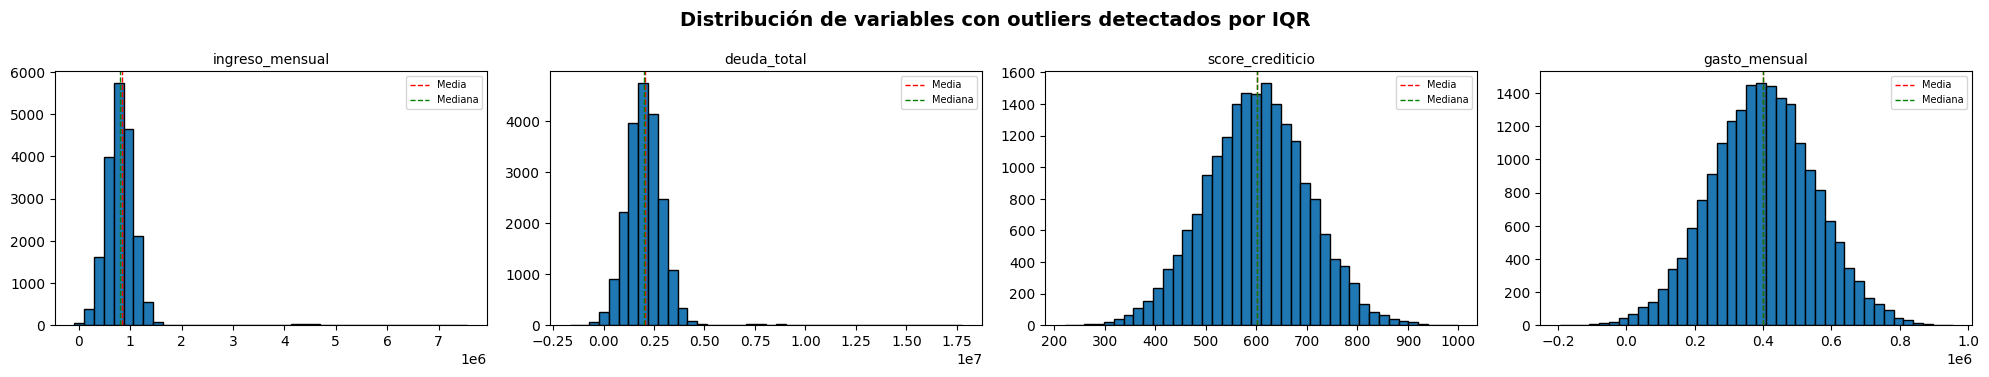

In [91]:
# Análisis visual solo de variables con outliers detectados por IQR
variables_con_outliers = (
    resumen_numericas.loc[resumen_numericas["n_outliers_iqr"] > 0, "variable"]
    .tolist()
)

if len(variables_con_outliers) == 0:
    print("IQR no detectó outliers en las variables numéricas.")
else:
    n_cols = 4
    n_rows = int(np.ceil(len(variables_con_outliers) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(variables_con_outliers):
        serie = data[col].dropna()
        axes[i].hist(serie, bins=40, edgecolor="black")
        axes[i].axvline(serie.mean(), color="red", linestyle="--", linewidth=1, label="Media")
        axes[i].axvline(serie.median(), color="green", linestyle="--", linewidth=1, label="Mediana")
        axes[i].set_title(col, fontsize=10)
        axes[i].legend(fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(
        "Distribución de variables con outliers detectados por IQR",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

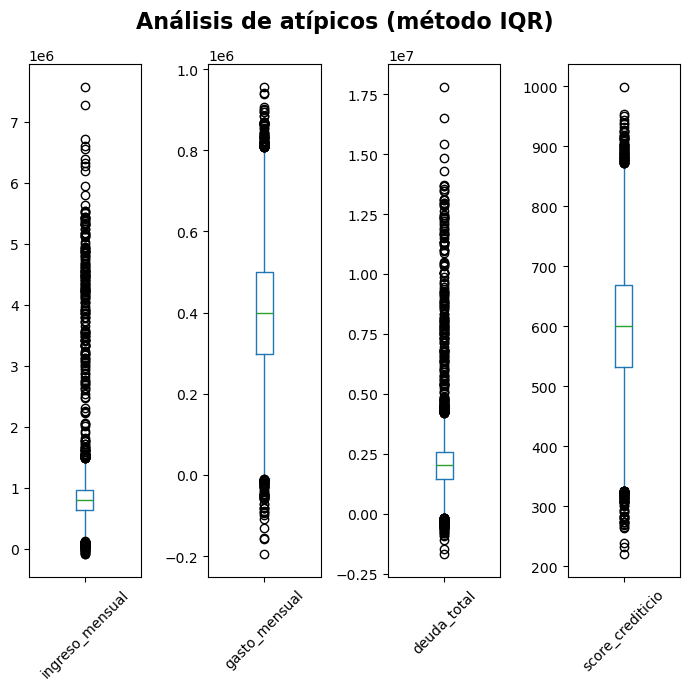

In [15]:
# Visualización de atípicos con boxplots (basados en IQR)
revision_atipicos = ["ingreso_mensual", "gasto_mensual", "deuda_total", "score_crediticio"]
fig, axes = plt.subplots(1, 4, figsize=(20, 20))
axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos):
    data[col].plot(kind='box', figsize=(7, 7), ax=axes[i])
    axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos (método IQR)", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

### Estadísticas antes de la limpieza

In [7]:
data.describe(include="object")

,fecha_registro,genero,region,estado_civil,uso_app,tipo_plan,canal_registro,dia_semana_registro
count,20400,20400,20400,20400,20400,20400,20400,20400
unique,2000,3,3,3,3,3,3,7
top,2018-06-14,Otro,Sur,Casado,Bajo,Estandar,App,Miercoles
freq,21,6997,6812,6828,6886,6878,6894,3000


In [97]:
data.genero.unique()

array(['Otro', 'Masculino', 'Femenino'], dtype=object)

## Pipeline: Limpieza + Transformación

En esta sección se ejecuta todo el flujo en un solo pipeline:
1. Eliminación de duplicados
2. Feature engineering
3. Limpieza (winsorización e imputación)
4. Transformación (escalado y codificación)

In [98]:
class Winsorizer(BaseEstimator, TransformerMixin):
    """
    Tratamiento de atípicos

    Parámetros
    ----------
    BaseEstimator : Clase base para estimadores en scikit-learn.
    TransformerMixin : Clase base para transformadores en scikit-learn.

    Atributos
    ---------
    columns_ : array-like
        Nombres de las columnas a transformar.
    limits : tuple
        % de los extremos a descartar
    """
    def __init__(self, limits=(0.05, 0.05)):
        self.limits = limits

    def fit(self, X, y=None):
        # Guardar nombres si es DataFrame, si no generar nombres genéricos
        if isinstance(X, pd.DataFrame):
            self.columns_ = X.columns
        else:
            self.columns_ = np.arange(X.shape[1])
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_)
        for col in self.columns_:
            lower = X[col].quantile(self.limits[0])
            upper = X[col].quantile(1 - self.limits[1])
            X = X.astype("float64")
            X[col] = np.clip(X[col], lower, upper)
        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array(self.columns_)
        else:
            return np.array(input_features)

In [99]:
def eliminar_duplicados(X: pd.DataFrame) -> pd.DataFrame:
    return X.drop_duplicates()


def agregar_variables_clientes(X: pd.DataFrame) -> pd.DataFrame:
    """Agrega variables derivadas para la etapa de transformación."""
    X = X.copy()
    eps = 1e-9

    X["ratio_gasto"] = X["gasto_mensual"] / (X["ingreso_mensual"] + eps)
    X["ratio_deuda_ingreso"] = X["deuda_total"] / (X["ingreso_mensual"] + eps)
    X["margen_ingreso"] = X["ingreso_mensual"] - X["gasto_mensual"]

    X["segmento_score"] = pd.cut(
        X["score_crediticio"],
        bins=[-np.inf, 500, 650, np.inf],
        labels=["Bajo", "Medio", "Alto"]
    )

    return X

Creamos la variable cliente porque esta es la que nos hará comprender la realidad del consumidor.

In [100]:
# Variables que se usarán en el pipeline
numeric_features = [
    "ingreso_mensual", "gasto_mensual", "deuda_total", "score_crediticio",
    "ratio_gasto", "ratio_deuda_ingreso", "margen_ingreso"
]

categorical_features = ["uso_app", "tipo_plan", "segmento_score", "genero", "region", "estado_civil", "canal_registro", "dia_semana_registro"]

In [101]:
# Define el pipeline para las variables cuantitativas
pipeline_numerico = Pipeline(
    steps=[
        ("winsorizer", Winsorizer()),
        ("imputacion", SimpleImputer(strategy="mean")),
        ("escalado", StandardScaler())
    ]
)

In [102]:
pipeline_categorico = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("codificacion", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

Pienso que acá hay un error. Por que deberian ser dos pipelines categoricos para el One hot encoder.

Estas variables son ordinales:
- genero
- region (Norte, Sur, Centro no implica que uno sea matemáticamente mayor que otro)
- estado_civil
- canal_registro
- dia_semana_registro

y estas nominales:

- uso_app (Bajo < Medio < Alto)

- tipo_plan (Básico < Estándar < Premium)

Por lo que en las ordinales deberíamos usar one hot encoder y en las nominales ordinal encoder

In [18]:
# Integra ambos pipelines
preprocesador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, numeric_features),
        ("cat", pipeline_categorico, categorical_features)
    ]
)

NameError: name 'pipeline_numerico' is not defined

In [104]:
# Define el pipeline (limpieza + transformación)
pipeline = Pipeline(
    steps=[
        ("duplicados", FunctionTransformer(eliminar_duplicados, validate=False)),
        ("feature_engineering", FunctionTransformer(agregar_variables_clientes, validate=False)),
        ("preprocesamiento", preprocesador)
    ]
)

Acá deberiamos borrar los datos inconsistentes?

In [105]:
# Aplica el pipeline
data_procesada_np = pipeline.fit_transform(data)

In [106]:
# Crea el DataFrame con los datos procesados
data_procesada = pd.DataFrame(
    data_procesada_np,
    columns=pipeline.named_steps["preprocesamiento"].get_feature_names_out()
)

# Limpia prefijos de nombres de columnas
data_procesada.columns = data_procesada.columns.str.replace("num__", "", regex=False)
data_procesada.columns = data_procesada.columns.str.replace("cat__", "", regex=False)
data_procesada[numeric_features] = data_procesada[numeric_features].apply(pd.to_numeric)

In [107]:
data_procesada.head()

,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,ratio_gasto,ratio_deuda_ingreso,margen_ingreso,uso_app_Alto,uso_app_Bajo,uso_app_Medio,...,canal_registro_App,canal_registro_Tienda,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes
0,5.299850e-01,0.928611,0.572725,-1.616594,0.092903,-0.083414,-0.027336,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.882364e+00,-0.634374,-0.531925,-0.283686,-1.245275,-1.134618,1.943037,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,5.168572e-16,-0.091109,1.848386,1.852509,0.000000,0.000000,0.000000,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-1.633970e+00,0.133372,1.308474,-1.757904,1.620503,2.472388,-1.505719,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-2.844893e-01,0.681851,-0.509044,-1.474195,0.469449,-0.394922,-0.611176,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [108]:
data_procesada.shape

(20000, 35)

### Estadísticas después del pipeline

In [109]:
data_procesada.describe()

,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,ratio_gasto,ratio_deuda_ingreso,margen_ingreso,uso_app_Alto,uso_app_Bajo,uso_app_Medio,...,canal_registro_App,canal_registro_Tienda,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes
count,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,3.822720e-16,2.373213e-16,2.007283e-16,2.749800e-16,-1.477929e-16,2.913225e-17,-3.268497e-17,0.332800,0.337450,0.329750,...,0.338150,0.331700,0.330150,0.142000,0.143350,0.143100,0.143350,0.146700,0.140150,0.141350
std,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,0.471227,0.472852,0.470134,...,0.473092,0.470836,0.470279,0.349059,0.350438,0.350184,0.350438,0.353815,0.347151,0.348391
min,-1.855212e+00,-1.850305e+00,-1.782402e+00,-1.874794e+00,-1.502748e+00,-1.459632e+00,-1.882512e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.103991e-01,-7.193767e-01,-7.426509e-01,-7.042625e-01,-7.045072e-01,-7.176664e-01,-6.749218e-01,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.168572e-16,4.335810e-16,-3.456175e-03,0.000000e+00,-6.435028e-02,-1.256367e-01,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.049931e-01,7.065437e-01,7.180967e-01,7.071144e-01,4.604963e-01,4.815631e-01,6.593367e-01,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.882364e+00,1.854910e+00,1.848386e+00,1.852509e+00,2.482932e+00,2.472388e+00,1.943037e+00,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [110]:
# Revisión robusta de categóricas post-transformación
columnas_categoricas = data_procesada.select_dtypes(include=["object", "category"]).columns

if len(columnas_categoricas) == 0:
    print("No hay columnas categóricas tipo object/category después del pipeline.")
    print("Esto es esperado cuando OneHotEncoder deja todo en formato numérico.")
else:
    display(data_procesada[columnas_categoricas].describe())

No hay columnas categóricas tipo object/category después del pipeline.
Esto es esperado cuando OneHotEncoder deja todo en formato numérico.


### Comparación visual

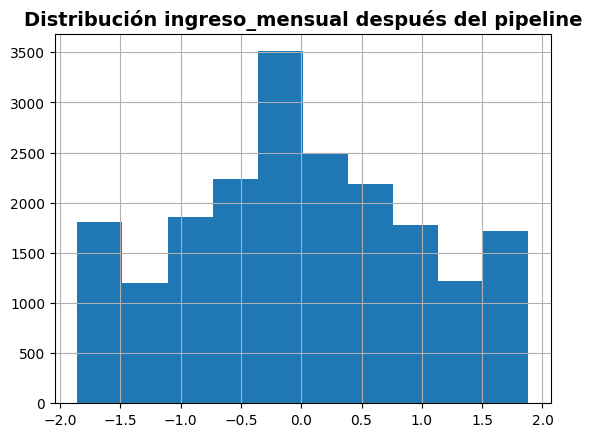

In [111]:
data_procesada['ingreso_mensual'].hist()
plt.title('Distribución ingreso_mensual después del pipeline', fontsize=14, fontweight='bold')
plt.show()

### Exportación de datos procesados

In [112]:
cwd = Path.cwd()

# Ajusta la raíz según dónde esté ejecutando VS Code el notebook
repo_root = cwd.parent

ruta_salida = repo_root / "outputs" / "dataset_clientes_procesado.csv"

# Crea la carpeta y guarda
ruta_salida.parent.mkdir(parents=True, exist_ok=True)
data_procesada.to_csv(ruta_salida, index=False, encoding='utf-8')

print(f"✅ Archivo exportado en: {ruta_salida}")

✅ Archivo exportado en: c:\Programacion_para_la_ciencia_de_datos\outputs\dataset_clientes_procesado.csv
